
# Trend Analysis: Cleaned Genre Frequency & Game Count Over Time (Fixed)
Using **effective_date_steam** and cleaned **categories** (noise removed).



In [43]:

import pandas as pd
import matplotlib.pyplot as plt
import ast
from collections import Counter

pd.set_option("display.max_colwidth", 200)

def parse_list(x):
    try:
        return ast.literal_eval(x) if isinstance(x,str) else (x if isinstance(x,list) else [])
    except Exception:
        return []

def merge_categories(row):
    cats=[]
    for col in ["categories_steam","categories_epic","categories_igdb"]:
        if col in row and isinstance(row[col], list):
            cats.extend([c for c in row[col] if isinstance(c,str)])
    return cats

# Noise keywords to remove platform/feature/meta tags
NOISE_KEYWORDS = [
    "steam", "cloud", "trading", "achive", "workshop", "remote", "controller",
    "full audio", "partial", "support", "windows", "mac", "linux",
    "single", "multi", "multiplayer", "coop", "co-op", "local",
    "vr", "pvp", "pve", "online", "cross-platform", "cross platform",
    "leaderboard", "dlc", "soundtrack", "demo", "work in progress", "indie", "early access"
]

def is_clean_genre(cat: str) -> bool:
    if not isinstance(cat, str):
        return False
    c = cat.lower()
    return not any(k in c for k in NOISE_KEYWORDS)

def make_monthly_count(series_indexed):
    # Drop NaT in index; resample monthly start
    s = series_indexed.dropna()
    if s.empty:
        return pd.Series(dtype="int64")
    return s.resample("MS").count()


## Load & Prepare Data

In [44]:
indie_path = '../data/gold/indie.csv'
notindie_path = '../data/gold/notindie.csv'
indie = pd.read_csv(indie_path)
notindie = pd.read_csv(notindie_path)

# Dates -> datetime
for df in [indie, notindie]:
    df["effective_date_steam"] = pd.to_datetime(df["effective_date_steam"], errors="coerce")

# Parse & merge categories
for df in [indie, notindie]:
    for col in ["categories_steam","categories_epic","categories_igdb"]:
        if col in df.columns:
            df[col] = df[col].apply(parse_list)
    df["all_categories"] = df.apply(merge_categories, axis=1)

# Clean categories
indie["clean_categories"] = indie["all_categories"].apply(lambda lst: [c for c in lst if is_clean_genre(c)])
notindie["clean_categories"] = notindie["all_categories"].apply(lambda lst: [c for c in lst if is_clean_genre(c)])


## Monthly Game Count Over Time (Indie vs Non‑Indie)

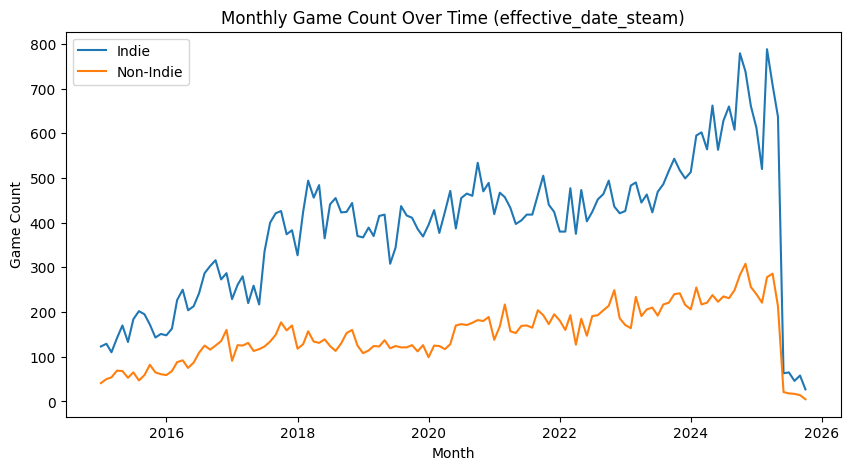

In [45]:

# Drop NaT rows before setting index
indie_valid = indie.dropna(subset=["effective_date_steam"]).copy().set_index("effective_date_steam")
not_valid   = notindie.dropna(subset=["effective_date_steam"]).copy().set_index("effective_date_steam")

indie_month_count = indie_valid["id"].resample("MS").count()
not_month_count   = not_valid["id"].resample("MS").count()

plt.figure(figsize=(10,5))
plt.plot(indie_month_count.index, indie_month_count.values, label="Indie")
plt.plot(not_month_count.index, not_month_count.values, label="Non‑Indie")
plt.xlabel("Month")
plt.ylabel("Game Count")
plt.title("Monthly Game Count Over Time (effective_date_steam)")
plt.legend()
plt.show()


## Identify Top Genres

In [46]:

all_clean = [c for row in indie["clean_categories"] for c in row] +             [c for row in notindie["clean_categories"] for c in row]

top_genres = [g for g, n in Counter(all_clean).most_common(10)]
top_genres


['Family Sharing',
 'Adventure',
 'Action',
 'Casual',
 'Strategy',
 'Simulator',
 'Simulation',
 'RPG',
 'Role-playing (RPG)',
 'Shooter']

## Monthly Genre Frequency — Indie

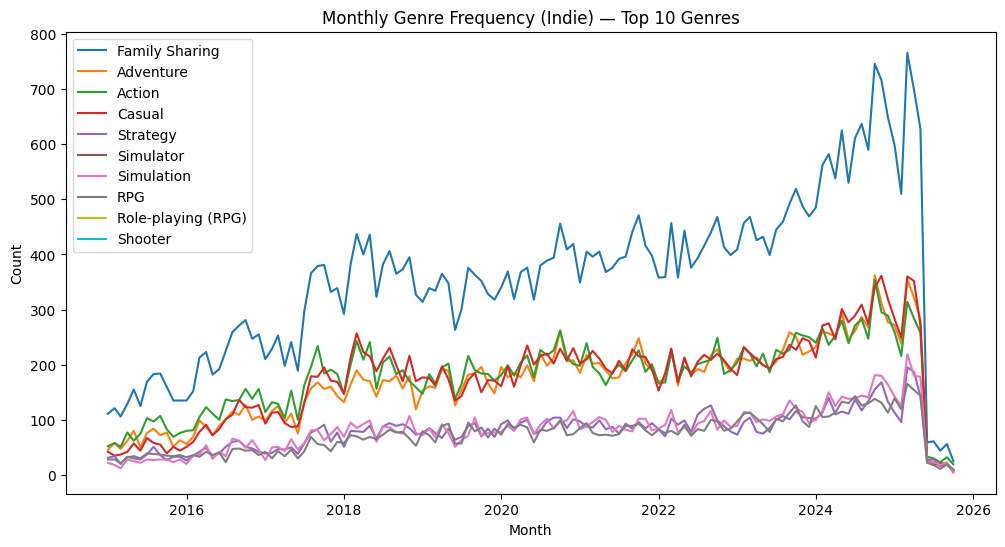

In [47]:

def genre_month_series(df, genre):
    # Keep only rows containing this genre
    df2 = df[df["clean_categories"].apply(lambda cats: genre in cats)].copy()
    # Drop NaT dates before resampling
    df2 = df2.dropna(subset=["effective_date_steam"])
    if df2.empty:
        return pd.Series(dtype="int64")
    s = df2.set_index("effective_date_steam")["id"]
    return s.resample("MS").count()

plt.figure(figsize=(12,6))
for g in top_genres:
    ser = genre_month_series(indie, g)
    plt.plot(ser.index, ser.values, label=g)
plt.title("Monthly Genre Frequency (Indie) — Top 10 Genres")
plt.xlabel("Month")
plt.ylabel("Count")
plt.legend()
plt.show()


## Monthly Genre Frequency — Non‑Indie (Top Genres)

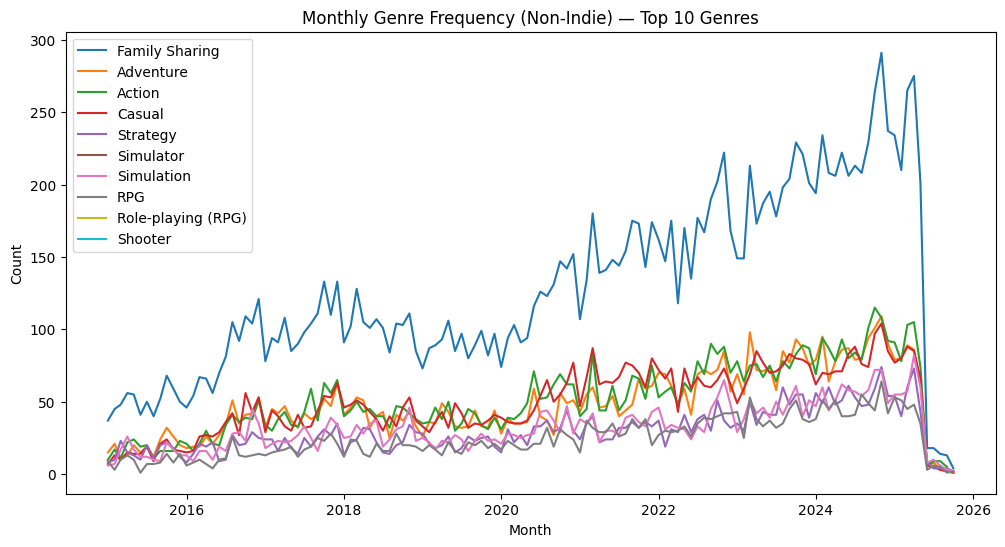

In [49]:

plt.figure(figsize=(12,6))
for g in top_genres:
    ser = genre_month_series(notindie, g)
    plt.plot(ser.index, ser.values, label=g)
plt.title("Monthly Genre Frequency (Non‑Indie) — Top 10 Genres")
plt.xlabel("Month")
plt.ylabel("Count")
plt.legend()
plt.show()


## (Optional) 3‑Month Rolling Smoothing — Indie Game Count

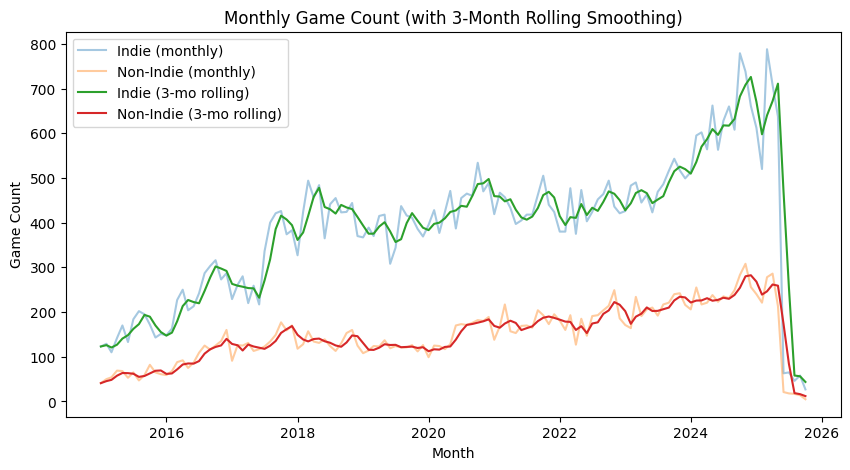

In [50]:

roll_indie = indie_month_count.rolling(3, min_periods=1).mean()
roll_not   = not_month_count.rolling(3, min_periods=1).mean()

plt.figure(figsize=(10,5))
plt.plot(indie_month_count.index, indie_month_count.values, alpha=0.4, label="Indie (monthly)")
plt.plot(not_month_count.index, not_month_count.values, alpha=0.4, label="Non‑Indie (monthly)")
plt.plot(roll_indie.index, roll_indie.values, label="Indie (3‑mo rolling)")
plt.plot(roll_not.index, roll_not.values, label="Non‑Indie (3‑mo rolling)")
plt.xlabel("Month")
plt.ylabel("Game Count")
plt.title("Monthly Game Count (with 3‑Month Rolling Smoothing)")
plt.legend()
plt.show()
